<a href="https://colab.research.google.com/github/gkrish088-blip/PCA-of-BTC-ETH-GL-SL/blob/main/PCA_of_BTC_GL_ETH_SL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Conclusion

We applied Principal Component Analysis (PCA) to one year of daily returns for Bitcoin, Ethereum, Gold, and Silver. The correlation matrix revealed two strongly correlated groups: cryptocurrencies (BTC and ETH) and precious metals (Gold and Silver), while correlations between the two groups were relatively weak.

The PCA decomposition showed that the first two principal components explain approximately 91.5% of the total variance in the dataset. The first principal component represents a broad market factor affecting all four assets, while the second principal component captures the relative performance of cryptocurrencies versus precious metals.

By projecting the original four-dimensional return space onto the first two principal components, we were able to retain most of the information contained in the data while reducing the dimensionality from four variables to two. This suggests that the behavior of these assets can be largely explained by two dominant underlying factors rather than four independent sources of risk.

Overall, the analysis demonstrates how PCA can identify hidden factor structures in financial markets and provide a more compact representation of asset return dynamics.


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np


In [8]:
tickers = ['BTC-USD' , 'ETH-USD' , 'GC=F' , 'SI=F']
data = yf.download(
    tickers,
    period='1y',
)


prices = data['Close']
return_matrix = prices.pct_change()
return_matrix.dropna(inplace=True)
print(type(return_matrix))

/tmp/ipykernel_6246/1295560426.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  4 of 4 completed

<class 'pandas.core.frame.DataFrame'>



/tmp/ipykernel_6246/1295560426.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return_matrix = prices.pct_change()


In [10]:
corr_matirx = return_matrix.corr() # this function already centers the returns to their means , like in theory we do B = X - Xbar nd then compute the corr , this corr() already does this
print(corr_matirx)



Ticker    BTC-USD   ETH-USD      GC=F      SI=F
Ticker                                         
BTC-USD  1.000000  0.856885  0.097194  0.138367
ETH-USD  0.856885  1.000000  0.090236  0.126112
GC=F     0.097194  0.090236  1.000000  0.804138
SI=F     0.138367  0.126112  0.804138  1.000000


In [15]:
eigvalues , eigvectors = np.linalg.eig(corr_matirx)   #eigenvectors will be column wise like we have in our mathematics the W matrix
idx = np.argsort(eigvalues)[::-1]

eigvalues = eigvalues[idx]
eigvectors = eigvectors[:, idx]
print(eigvalues)
print(eigvectors)

for i in range(len(eigvalues)):
  print(f"Var explained by PC {i+1} having  Variance / eigvalue {eigvalues[i]} is {eigvalues[i] / eigvalues.sum() *100 } % " )



[2.05846654 1.60352361 0.19508957 0.14292029]
[[-0.53087725 -0.46601543  0.01971335 -0.70753823]
 [-0.52613594 -0.47292334 -0.05302235  0.70477878]
 [-0.45869901  0.54144521 -0.70384971 -0.03206073]
 [-0.48056793  0.51576178  0.70809293  0.04060349]]
Var explained by PC 1 having  Variance / eigvalue 2.0584665402571707 is 51.46166350642931 % 
Var explained by PC 2 having  Variance / eigvalue 1.6035236060729638 is 40.08809015182413 % 
Var explained by PC 3 having  Variance / eigvalue 0.19508956862029841 is 4.877239215507464 % 
Var explained by PC 4 having  Variance / eigvalue 0.14292028504956417 is 3.5730071262391068 % 


In [20]:
standardized_returns = (
    return_matrix - return_matrix.mean()
) / return_matrix.std()

pc_scores = np.dot(standardized_returns , eigvectors)
print(pc_scores)

[[ 0.45674893 -0.19775142  0.26131446  0.0181805 ]
 [-0.11230375  0.24014383 -0.36558125  0.2929734 ]
 [ 1.60799318  1.79773467  1.14052772 -0.47900525]
 ...
 [-0.65534719  0.77459309 -0.9992625   0.04843414]
 [-0.12916112 -0.25686358 -0.01141091 -0.11551011]
 [ 0.11562373 -0.03926793 -0.00268332 -0.13451621]]


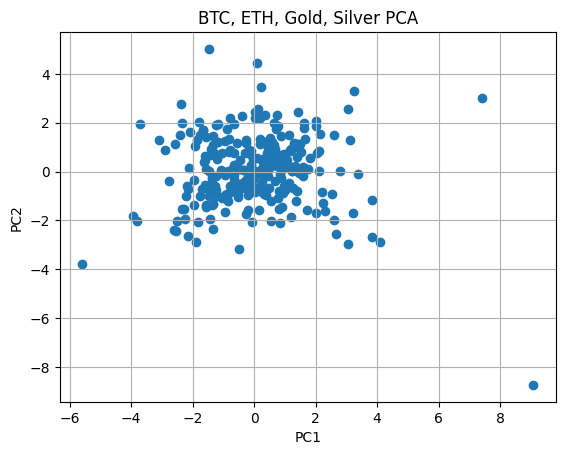

In [22]:
import matplotlib.pyplot as plt

plt.scatter(
    pc_scores[:,0],
    pc_scores[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.title("BTC, ETH, Gold, Silver PCA")
plt.show()